In [106]:
from ucimlrepo import fetch_ucirepo, list_available_datasets
# fetch dataset 
nursery = fetch_ucirepo(id=76) 

In [143]:
## Imporat relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import roc_curve, auc

In [108]:
# Get full dataset (features + target together)
df = nursery.data.original

print(df.shape)
df

(12960, 9)


,parents,has_nurs,form,children,housing,finance,social,health,class
0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority
...,...,...,...,...,...,...,...,...,...
12955,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,priority,spec_prior
12956,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,not_recom,not_recom
12957,great_pret,very_crit,foster,more,critical,inconv,problematic,recommended,spec_prior
12958,great_pret,very_crit,foster,more,critical,inconv,problematic,priority,spec_prior


### EDA

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   parents   12960 non-null  object
 1   has_nurs  12960 non-null  object
 2   form      12960 non-null  object
 3   children  12960 non-null  object
 4   housing   12960 non-null  object
 5   finance   12960 non-null  object
 6   social    12960 non-null  object
 7   health    12960 non-null  object
 8   class     12960 non-null  object
dtypes: object(9)
memory usage: 911.4+ KB


In [110]:
df.shape

(12960, 9)

In [111]:
### Check missing values
df.isnull().sum()

parents     0
has_nurs    0
form        0
children    0
housing     0
finance     0
social      0
health      0
class       0
dtype: int64

In [112]:
## Unique values per column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

parents: 3 unique values
has_nurs: 5 unique values
form: 4 unique values
children: 4 unique values
housing: 3 unique values
finance: 2 unique values
social: 3 unique values
health: 3 unique values
class: 5 unique values


In [113]:
df['class'].value_counts(normalize=True)

class
not_recom     0.333333
priority      0.329167
spec_prior    0.312037
very_recom    0.025309
recommend     0.000154
Name: proportion, dtype: float64

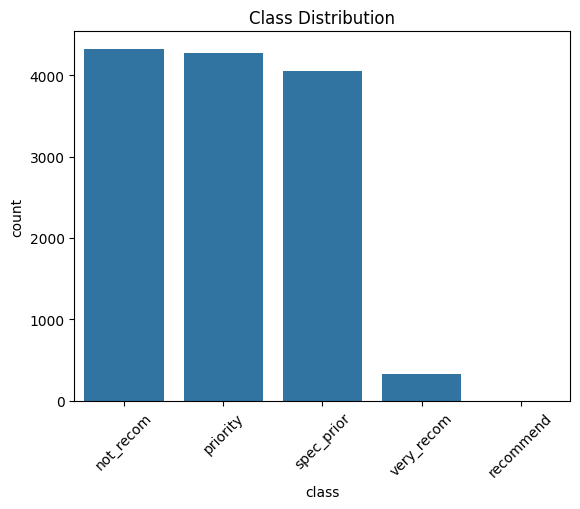

In [114]:
sns.countplot(data=df, x='class', order=df['class'].value_counts().index)
plt.title('Class Distribution')
plt.xticks(rotation=45)
plt.show()

In [115]:
df['class'] = df['class'].replace({'recommend': 'very_recom'}) # Merge recommend and very_recom

In [116]:
df['class'].value_counts(normalize=True)

class
not_recom     0.333333
priority      0.329167
spec_prior    0.312037
very_recom    0.025463
Name: proportion, dtype: float64

In [117]:
for col in df.columns:
    print(f"Column: {col}")
    print(f"Unique values ({df[col].nunique()}): {df[col].unique()}")
    print(df[col].value_counts())  # proportion of each category
    print("-"*40)


Column: parents
Unique values (3): ['usual' 'pretentious' 'great_pret']
parents
usual          4320
pretentious    4320
great_pret     4320
Name: count, dtype: int64
----------------------------------------
Column: has_nurs
Unique values (5): ['proper' 'less_proper' 'improper' 'critical' 'very_crit']
has_nurs
proper         2592
less_proper    2592
improper       2592
critical       2592
very_crit      2592
Name: count, dtype: int64
----------------------------------------
Column: form
Unique values (4): ['complete' 'completed' 'incomplete' 'foster']
form
complete      3240
completed     3240
incomplete    3240
foster        3240
Name: count, dtype: int64
----------------------------------------
Column: children
Unique values (4): ['1' '2' '3' 'more']
children
1       3240
2       3240
3       3240
more    3240
Name: count, dtype: int64
----------------------------------------
Column: housing
Unique values (3): ['convenient' 'less_conv' 'critical']
housing
convenient    4320
less_conv 

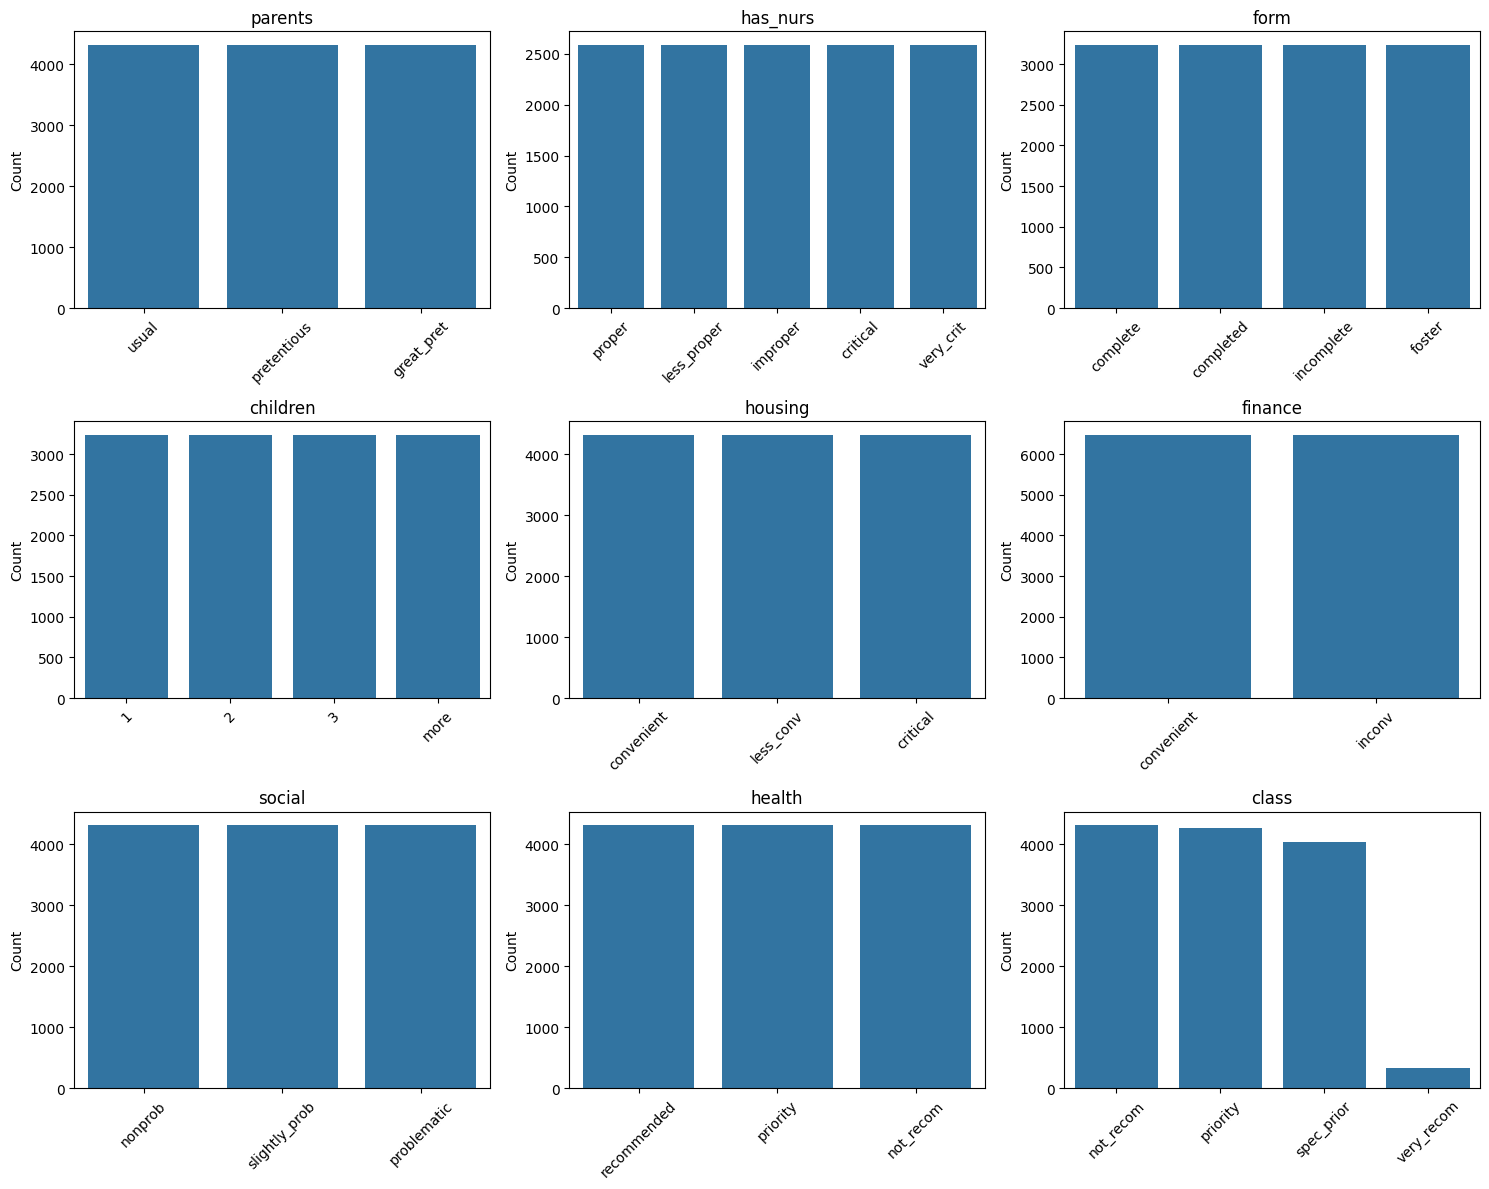

In [118]:
cols = df.columns
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))

for i, col in enumerate(cols):
    ax = axes[i // n_cols, i % n_cols]
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax)
    ax.set_title(f"{col}")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

# Hide empty subplots if any
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()


In [119]:
# Train /test/validation split
from sklearn.model_selection import train_test_split
df_full_train , df_test = train_test_split(df, test_size = 0.2, random_state = 11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state =11)

In [120]:
df_train = df_train.reset_index(drop =True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [121]:
len(df_train), len(df_val), len(df_test)

(7776, 2592, 2592)

In [122]:
# Separate features 
df_train_f = df_train.drop('class', axis=1)
df_val_f = df_val.drop('class', axis=1)
df_test_f = df_test.drop('class', axis=1)

In [123]:
## Target Features
y_train = df_train['class']
y_val = df_val['class']
y_test = df_test['class']

In [124]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

print(le.classes_)   # shows mapping like ['not_recom', 'priority', 'spec_prior', 'very_recom']

['not_recom' 'priority' 'spec_prior' 'very_recom']


### Decision Tress Model

In [125]:
dv = DictVectorizer(sparse = False)
X_train = dv.fit_transform(df_train_f.to_dict(orient='records'))
X_val = dv.transform(df_val_f.to_dict(orient='records'))
X_test = dv.transform(df_test_f.to_dict(orient='records'))

In [126]:
dt = DecisionTreeClassifier(max_depth=1)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [127]:
val_dicts = df_val.to_dict(orient = 'records')
X_val = dv.transform(val_dicts)

In [128]:
y_pred = dt.predict_proba(X_val)
roc_auc = roc_auc_score(y_val, y_pred, multi_class='ovr', average='macro')

print("ROC-AUC score:", roc_auc)

ROC-AUC score: 0.7889221415013022


### Feature Importance

In [129]:
feat_importance = pd.Series(dt.feature_importances_, index=dv.get_feature_names_out())
feat_importance.sort_values(ascending=False).head(10)


health=not_recom       1.0
children=1             0.0
has_nurs=very_crit     0.0
social=problematic     0.0
social=nonprob         0.0
parents=usual          0.0
parents=pretentious    0.0
parents=great_pret     0.0
housing=less_conv      0.0
housing=critical       0.0
dtype: float64

### Parameter Tuning

In [130]:
depths = [3, 5, 7, 9, 12, 15, 18, 21]
roc_auc_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d,random_state=11)
    dt.fit(X_train, y_train)

    y_val_proba = dt.predict_proba(X_val)

    roc_auc = roc_auc_score(y_val, y_val_proba, multi_class='ovr', average='macro')
    roc_auc_scores.append(roc_auc)


    print(f"max_depth={d}, Validation ROC-AUC={roc_auc:.4f}")    

max_depth=3, Validation ROC-AUC=0.8974
max_depth=5, Validation ROC-AUC=0.9535
max_depth=7, Validation ROC-AUC=0.9863
max_depth=9, Validation ROC-AUC=0.9964
max_depth=12, Validation ROC-AUC=0.9972
max_depth=15, Validation ROC-AUC=0.9960
max_depth=18, Validation ROC-AUC=0.9960
max_depth=21, Validation ROC-AUC=0.9960


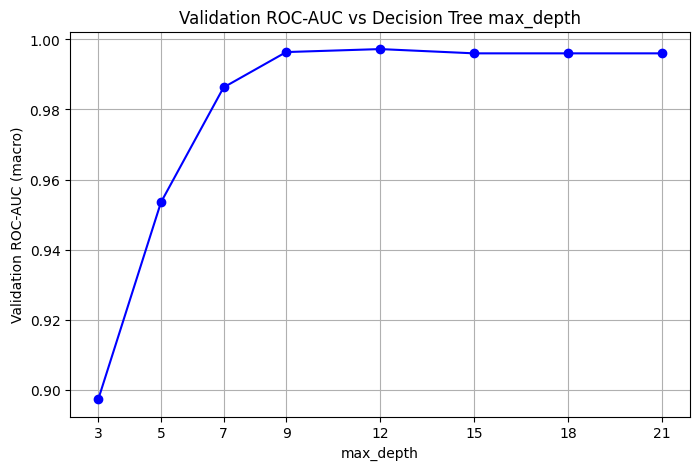

In [131]:
# Plotting
plt.figure(figsize=(8,5))
plt.plot(depths, roc_auc_scores, marker='o', linestyle='-', color='blue')
plt.title('Validation ROC-AUC vs Decision Tree max_depth')
plt.xlabel('max_depth')
plt.ylabel('Validation ROC-AUC (macro)')
plt.xticks(depths)
plt.grid(True)
plt.show()

In [132]:
# min_samples_split
scores = []
for d in [3, 5, 7, 9, 12, 15, 18, 21]:
    for l in range(2, 10, 2):
        dt = DecisionTreeClassifier(max_depth=d, min_samples_split=l, random_state=11)
        dt.fit(X_train, y_train)

        y_val_proba = dt.predict_proba(X_val)

        roc_auc = roc_auc_score(y_val, y_val_proba, multi_class='ovr', average='macro')
        scores.append((d, l, roc_auc))


    #print(f"max_depth={d}, min_samples_split={l}, Validation ROC-AUC={roc_auc:.4f}")

In [133]:
columns = ['max_depth', 'min_samples_split', 'roc_auc']
df_scores_d = pd.DataFrame(scores, columns = columns)
df_scores_d

,max_depth,min_samples_split,roc_auc
0,3,2,0.897363
1,3,4,0.897363
2,3,6,0.897363
3,3,8,0.897363
4,5,2,0.953500
5,5,4,0.953500
6,5,6,0.953500
7,5,8,0.953500
8,7,2,0.986295
9,7,4,0.986295


In [134]:
scores = []
for d in [3, 5, 7, 9, 12, 15, 18, 21]:
    for l in range(2, 10, 2):
        dt = DecisionTreeClassifier(max_depth=d, min_samples_split=l, random_state=11)
        dt.fit(X_train, y_train)

        y_val_proba = dt.predict_proba(X_val)
        roc_auc = roc_auc_score(y_val, y_val_proba, multi_class='ovr', average='macro')
        
        scores.append((d, l, roc_auc))
        # Print inside the inner loop
        #print(f"max_depth={d}, min_samples_split={l}, Validation ROC-AUC={roc_auc:.4f}")


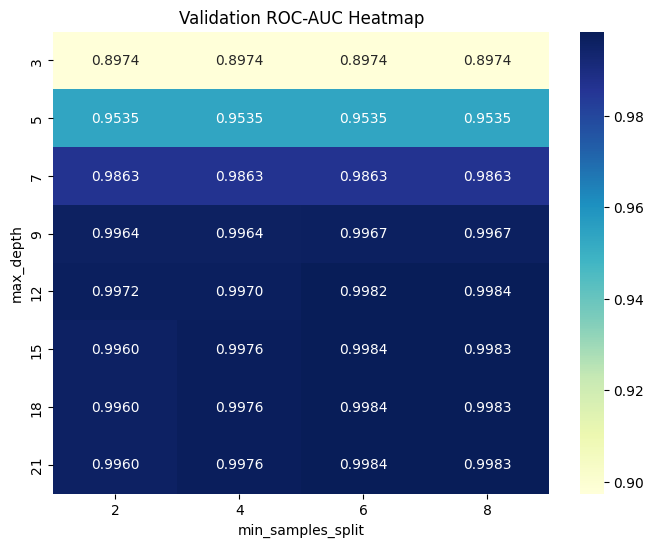

In [135]:
import pandas as pd
import seaborn as sns

# Convert scores to DataFrame
df_scores = pd.DataFrame(scores, columns=['max_depth','min_samples_split','roc_auc'])

# Pivot table for heatmap
heatmap_data = df_scores.pivot(index='max_depth', columns='min_samples_split', values='roc_auc')

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title('Validation ROC-AUC Heatmap')
plt.xlabel('min_samples_split')
plt.ylabel('max_depth')
plt.show()


In [136]:
# min_samples_leaf
scores_leaf = []
for d in [3, 5, 7, 9, 12, 15, 18, 21]:
    for l in range(2, 10, 2):
        for m in range(1, 20, 2):
            dt = DecisionTreeClassifier(max_depth=d, 
                                        min_samples_split=l, 
                                        min_samples_leaf=m, 
                                        random_state=11)
            dt.fit(X_train, y_train)

            y_val_proba = dt.predict_proba(X_val)
            roc_auc = roc_auc_score(y_val, y_val_proba, multi_class='ovr', average='macro')
            
            scores_leaf.append((d, l, m, roc_auc))
            # Print inside the inner loop
            #print(f"max_depth={d}, min_samples_split={l}, min_samples_leaf={m}, Validation ROC-AUC={roc_auc:.4f}")


In [137]:
columns = ['max_depth', 'min_samples_split', 'min_samples_leaf', 'roc_auc']
df_scores_leaf = pd.DataFrame(scores_leaf, columns=columns)
df_scores_leaf

,max_depth,min_samples_split,min_samples_leaf,roc_auc
0,3,2,1,0.897363
1,3,2,3,0.897363
2,3,2,5,0.897363
3,3,2,7,0.897363
4,3,2,9,0.897363
...,...,...,...,...
315,21,8,11,0.998053
316,21,8,13,0.998121
317,21,8,15,0.997748
318,21,8,17,0.996990


In [142]:
best_row = df_scores_leaf.loc[df_scores_leaf['roc_auc'].idxmax()]
print(best_row)


max_depth            12.000000
min_samples_split     2.000000
min_samples_leaf      7.000000
roc_auc               0.998552
Name: 163, dtype: float64
